# Dosing Example 

Using either forcing functions or events to administer doses

This model has three inputs that can be described through RHS forcing functions:
* OralExp - switch for oral dosing event
* IVExp - seitch for IV dosing event
* M_in - Mass of individual over time

Each exp event can be modeled through the continuous forcing function:

$$
\begin{align}
  f(t) = \frac{\text{tanh}(s * (t - t_0)) - \text{tanh}(s * (t - t_1))}{2}
\end{align}
$$

where $t_0$ is the start time of the dose, $t_1$ is the end time of the dose, and $s$ is a steepness parameter that controls how quickly the function transitions from 0 to 1. A higher value of $s$ results in a steeper transition.

The OnOff for the forcing functions are implemented throuhgh `PerDose` where a periodic dosing schedule can be defined and `NDoses` where the total number of doses to be administered is defined.

Additionally, interpolation functions or constant value functions can be used to define time-varying inputs such as body weight (`M_in`). This is accomplished by designating an `'Interpolate'` forcing_function followed by the `times` and `values` for the input variable.

Finally, all inputs are assigned a `ZeroFunc` by default which makes all inputs zero for all times unless a function is assigned.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from rich import print
import numpy as np
import matplotlib.pyplot as plt
import jax
print(jax.devices())

from pymcsimmod.parser import ModelParser

from pymcsimmod import create_model, JaxModel, ScipyModel

[CpuDevice(id=0)]

## Using PyMCSimMod Interface

This package provides a unified `create_model()` function that allows you to create models with different backends:

In [2]:
import importlib.resources
with importlib.resources.path('pymcsimmod.data', 'pk1_input.model') as filename:
    pk1_jax = create_model(filename, backend="jax")
    pk1_scipy = create_model(filename, backend="scipy")

# Scipy model

## Example 1

Periodic dosing every 7 days, with constant body mass

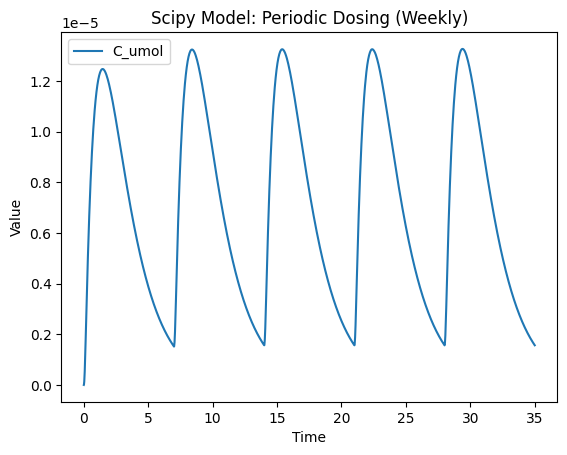

In [3]:
scipy_model = ScipyModel(model=filename)
scipy_model.update_constants(OralDose=50)
scipy_model.assign_forcing_function(
    'M_in', 
    'ConstFunc', 
    value = 70.0  # Constant body weight of 70 kg
)

scipy_model.assign_forcing_function(
    'OralExp', 
    'PerDose', 
    t0=0, 
    duration=scipy_model.parameters['OralDur'], 
    period=7,
    s=10.0  # Custom smoothing parameter (default is 10.0)
)

times = np.linspace(0, 35, 1000)
solution = scipy_model.run_model(times)
solution.plot_results(variables=['C_umol'])
plt.title('Scipy Model: Periodic Dosing (Weekly)')
plt.show()

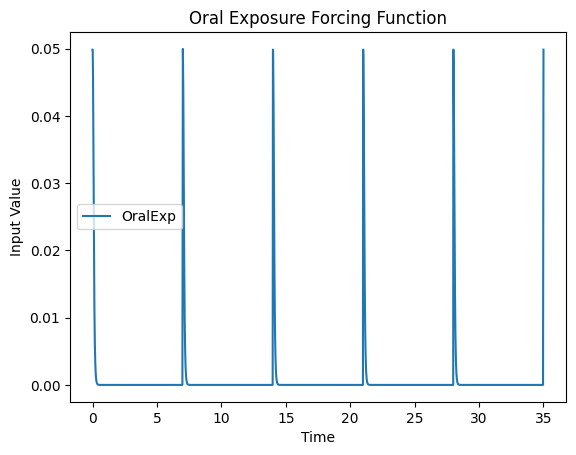

In [4]:
# Plot the forcing function input
solution.plot_inputs(variables='OralExp')
plt.title('Oral Exposure Forcing Function')
plt.show()

## Example 2

Periodic dosing every 7 days, with measured body mass and interpolation between measured points

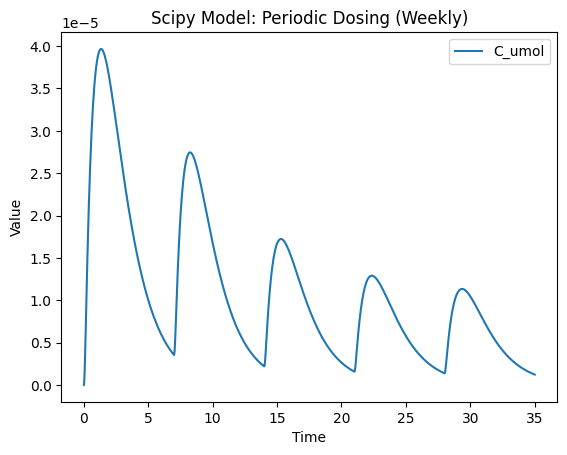

In [5]:
scipy_model = ScipyModel(model=filename)
scipy_model.update_constants(OralDose=50)

time_points = [0, 7, 14, 21, 28, 35]  # weeks
bodyweights = [20, 30, 50, 70, 80, 90]  # kg
scipy_model.assign_forcing_function('M_in', "Interpolate", times=time_points, values=bodyweights)

scipy_model.assign_forcing_function(
    'OralExp', 
    'PerDose', 
    t0=0, 
    duration=scipy_model.parameters['OralDur'], 
    period=7,
    s=10.0  # Custom smoothing parameter (default is 10.0)
)

times = np.linspace(0, 35, 1000)
solution = scipy_model.run_model(times)
solution.plot_results(variables=['C_umol'])
plt.title('Scipy Model: Periodic Dosing (Weekly)')
plt.show()

## Discrete Events Example

This demonstrates the new discrete events functionality similar to deSolve's event handling.
The discrete events system allows you to:
- **Add** to a state variable at specific times
- **Replace** a state variable value at specific times  
- **Multiply** a state variable by a factor at specific times

This is useful for modeling things like:
- Additional drug doses at specific times
- Bolus injections
- Sudden changes in system state
- Discrete interventions

**Note**: Discrete events are currently only supported in `ScipyModel`, not `JaxModel`.

/data/tzurlind/Desktop/PKWG/PyMCSimMod/src/pymcsimmod/models/scipy_model.py:198: UserWarning: Event times [np.float64(5.0), np.float64(10.0), np.float64(15.0)] not found in time grid - automatically adding them to ensure accurate event handling. To avoid this message, consider using: np.arange(0.0, 20.020, 0.020) or explicitly include event times in your time array.
  validated_events, modified_times = check_events(self.events, times, self.state_names)
/data/tzurlind/Desktop/PKWG/PyMCSimMod/src/pymcsimmod/models/scipy_model.py:198: UserWarning: Removed 1 time points that were within numerical precision of event times to avoid numerical issues. This is normal behavior following deSolve's event handling.
  validated_events, modified_times = check_events(self.events, times, self.state_names)


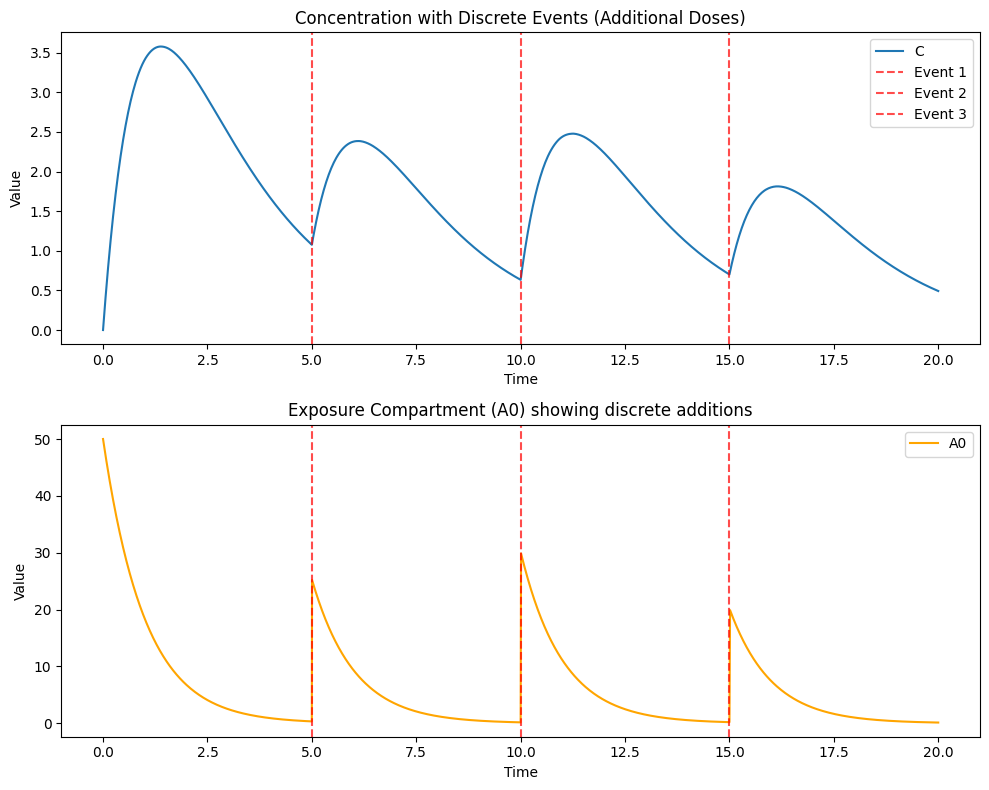

In [6]:
# Example 1: Adding additional doses using discrete events
# This shows how to add discrete "add" events for additional dosing
with importlib.resources.path('pymcsimmod.data', 'pk1_input.model') as filename:
    scipy_model_events = create_model(filename, backend="scipy")

# Assign forcing function to the correct model instance
scipy_model_events.assign_forcing_function(
    'M_in', 
    'ConstFunc', 
    value = 70.0  # Constant body weight of 70 kg
)

# Add discrete events - additional doses at specific times
# Each event adds to the A0 compartment (exposure compartment)
scipy_model_events.add_event(time=0.0, state_var='A0', value=50.0, method='add')  # Initial Dose at t=0
scipy_model_events.add_event(time=5.0, state_var='A0', value=25.0, method='add')  # Dose at t=5
scipy_model_events.add_event(time=10.0, state_var='A0', value=30.0, method='add') # Dose at t=10  
scipy_model_events.add_event(time=15.0, state_var='A0', value=20.0, method='add') # Dose at t=15

# Run the model
times = np.linspace(0, 20, 1000)
solution_events = scipy_model_events.run_model(times)

# Plot the results
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot concentration
solution_events.plot_results(variables='C', ax=ax1)
ax1.set_title('Concentration with Discrete Events (Additional Doses)')
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Event 1')
ax1.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='Event 2')
ax1.axvline(x=15, color='red', linestyle='--', alpha=0.7, label='Event 3')
ax1.legend()

# Plot A0 (exposure compartment) to see the discrete jumps
solution_events.plot_results(variables='A0', ax=ax2, color='orange')
ax2.set_title('Exposure Compartment (A0) showing discrete additions')
ax2.axvline(x=5, color='red', linestyle='--', alpha=0.7)
ax2.axvline(x=10, color='red', linestyle='--', alpha=0.7)
ax2.axvline(x=15, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Number of events before clearing: 3

Events:
[(0.0, 'A0', 30.0, 'add'), (2.0, 'A0', 10.0, 'add'), (8.0, 'A0', 15.0, 'add')]

Number of events after clearing: 0

Number of events after adding one: 2

Event times between 0 and 10: [0.0, 5.0]

/data/tzurlind/Desktop/PKWG/PyMCSimMod/src/pymcsimmod/models/scipy_model.py:198: UserWarning: Event times [np.float64(5.0)] not found in time grid - automatically adding them to ensure accurate event handling. To avoid this message, consider using: np.arange(0.0, 10.020, 0.020) or explicitly include event times in your time array.
  validated_events, modified_times = check_events(self.events, times, self.state_names)


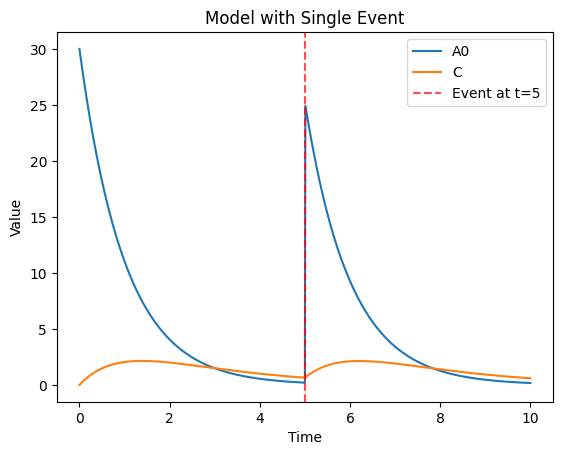

In [7]:
# Example 3: Clearing and managing events
# Show how to clear events and manage them

scipy_model_clear = ScipyModel(model=filename)

# Assign forcing function to the correct model instance
scipy_model_clear.assign_forcing_function(
    'M_in', 
    'ConstFunc', 
    value = 70.0  # Constant body weight of 70 kg
)

# Add some events
scipy_model_clear.add_event(time=0.0, state_var='A0', value=30, method='add')
scipy_model_clear.add_event(time=2.0, state_var='A0', value=10, method='add')
scipy_model_clear.add_event(time=8.0, state_var='A0', value=15, method='add')

print(f"Number of events before clearing: {len(scipy_model_clear.events)}")
print("Events:", [(e.time, e.state_var, e.value, e.method) for e in scipy_model_clear.events])

# Clear all events
scipy_model_clear.clear_events()
print(f"Number of events after clearing: {len(scipy_model_clear.events)}")

# Add a single event
scipy_model_clear.add_event(time=0.0, state_var='A0', value=30, method='add')
scipy_model_clear.add_event(time=5.0, state_var='A0', value=25, method='add')
print(f"Number of events after adding one: {len(scipy_model_clear.events)}")

# Get event times within a range
event_times = scipy_model_clear.get_event_times(0, 10)
print(f"Event times between 0 and 10: {event_times}")

# Run model
times = np.linspace(0, 10, 500)
solution_clear = scipy_model_clear.run_model(times)
solution_clear.plot_results(variables=['A0', 'C'])
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Event at t=5')
plt.legend()
plt.title('Model with Single Event')
plt.show()

# JAX Model Examples

JAX models provide fast compilation and execution but have some limitations (e.g., no discrete events).

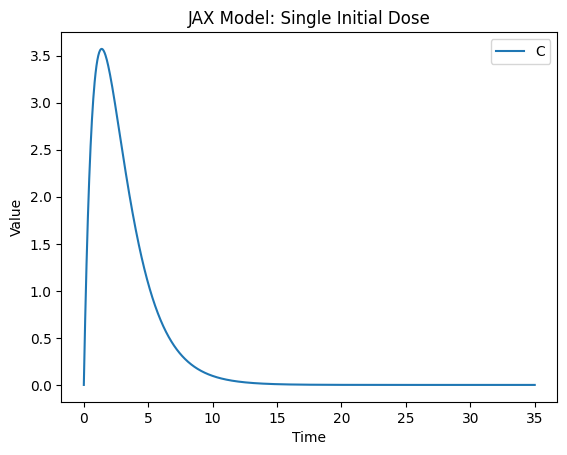

CPU times: user 2.67 s, sys: 380 ms, total: 3.05 s
Wall time: 2.04 s


In [8]:
%%time
# Example 1: Simple JAX model without forcing functions
jax_model = JaxModel(model=filename)
jax_model.update_Y0(A0=50.0)  # Initial dose
jax_model.assign_forcing_function(
    'M_in', 
    'ConstFunc', 
    value = 70.0  # Constant body weight of 70 kg
)
times = np.linspace(0, 35, 1000)
solution = jax_model.run_model(times)
solution.plot_results(variables='C')
plt.title('JAX Model: Single Initial Dose')
plt.show()

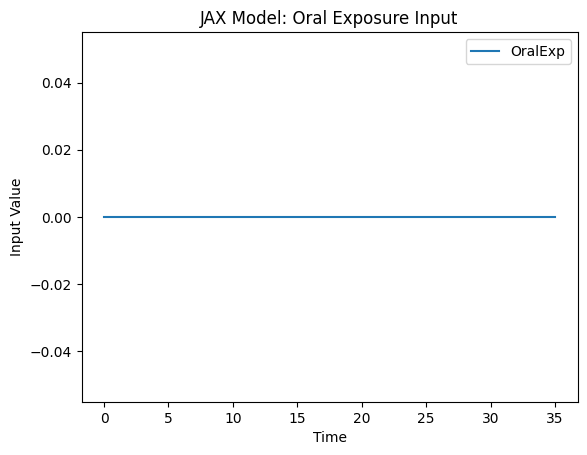

In [9]:
# Plot inputs for JAX model (default was ZeroFunc)
solution.plot_inputs(variables='OralExp')
plt.title('JAX Model: Oral Exposure Input')
plt.show()

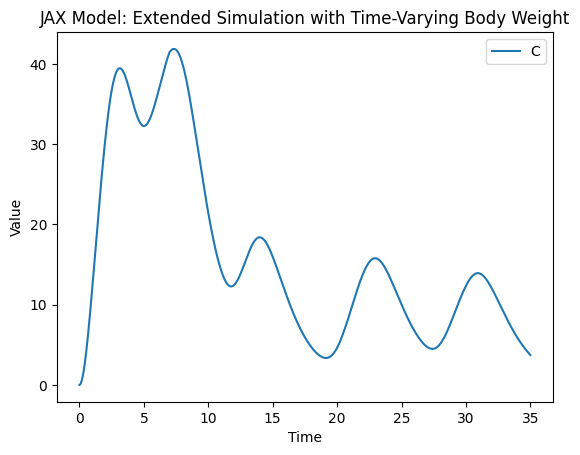

In [10]:
# Alternative: Original time range with better solver settings
# If you need to use the original longer time points, extend simulation time:

jax_model_doses_long = create_model(filename, backend="jax")
jax_model_doses_long.update_constants(OralDose=100)

# Original time points (but extend simulation to cover them)
time_points_long = [0, 7, 14, 21, 28, 35]  # weeks
bodyweights_long = [20, 30, 50, 70, 80, 90]  # kg
jax_model_doses_long.assign_forcing_function('M_in', 'Interpolate', times=time_points_long, values=bodyweights_long)

jax_model_doses_long.assign_forcing_function(
    'OralExp', 
    'NDoses', 
    t0_list=[0, 1, 2, 5, 6, 7, 12, 13, 20, 21, 22, 28, 29, 30], # More doses
    duration=jax_model_doses_long.parameters['OralDur'],
    s=1.0  # Mild stiffness for stability
)

# Extend simulation time to match data range
times_long = np.linspace(0, 35, 1000)

# Use implicit solver for better stability with complex forcing functions
solution_long = jax_model_doses_long.run_model(
    times_long, 
    #max_steps=300000, 
    rtol=1e-5, 
    atol=1e-5
)
solution_long.plot_results(variables='C')
plt.title('JAX Model: Extended Simulation with Time-Varying Body Weight')
plt.show()

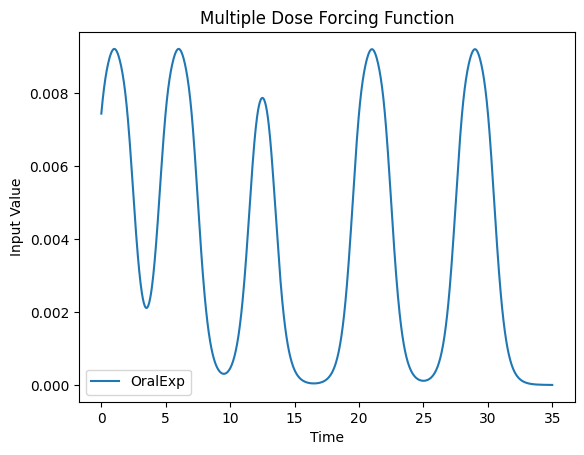

In [11]:
# Plot the multiple dose forcing function
solution_long.plot_inputs(variables='OralExp')
plt.title('Multiple Dose Forcing Function')
plt.show()

In [12]:
# Check the oral duration parameter
print(f"Oral duration parameter: {jax_model_doses_long.parameters['OralDur']}")

Oral duration parameter: 0.01

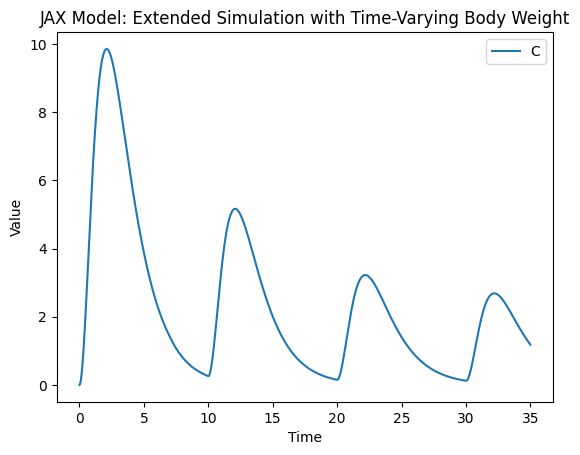

In [13]:
# PerDose Example

jax_model_perdose = create_model(filename, backend="jax")
jax_model_perdose.update_constants(OralDose=100)

# Original time points (but extend simulation to cover them)
time_points = [0, 7, 14, 21, 28, 35]  # weeks
bodyweights = [20, 30, 50, 70, 80, 90]  # kg

jax_model_perdose.assign_forcing_function('M_in', 'Interpolate', times=time_points, values=bodyweights)

jax_model_perdose.assign_forcing_function(
    'OralExp', 
    'PerDose',
    t0=0, 
    period=10,
    duration=jax_model_perdose.parameters['OralDur'],
    s=1.0  # Mild stiffness for stability
)

# Extend simulation time to match data range
times_perdose = np.linspace(0, 35, 1000)

# Use implicit solver for better stability with complex forcing functions
solution_perdose = jax_model_perdose.run_model(
    times_perdose, 
    max_steps=300000, 
    rtol=1e-4, 
    atol=1e-4
)
solution_perdose.plot_results(variables='C')
plt.title('JAX Model: Extended Simulation with Time-Varying Body Weight')
plt.show()

Number of events before clearing: 2

Events:
[(2.0, 'A0', 10.0, 'add'), (8.0, 'A0', 15.0, 'add')]

Number of events after clearing: 0

Number of events after adding one: 1

Event times between 0 and 10: [5.0]

/data/tzurlind/Desktop/PKWG/PyMCSimMod/src/pymcsimmod/models/scipy_model.py:198: UserWarning: Event times [np.float64(5.0)] not found in time grid - automatically adding them to ensure accurate event handling. To avoid this message, consider using: np.arange(0.0, 10.020, 0.020) or explicitly include event times in your time array.
  validated_events, modified_times = check_events(self.events, times, self.state_names)


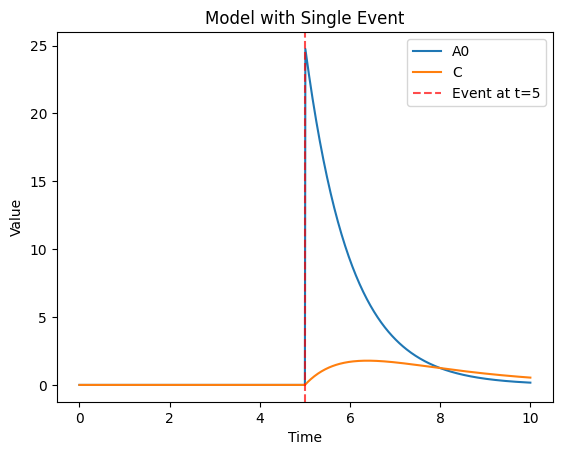

In [14]:
# Example 3: Clearing and managing events
# Show how to clear events and manage them

scipy_model_clear = ScipyModel(model=filename)
scipy_model_clear.update_constants(OralDose=30)
scipy_model_clear.assign_forcing_function('M_in', 'ConstFunc', value=70.0)

# Add some events
scipy_model_clear.add_event(time=2.0, state_var='A0', value=10, method='add')
scipy_model_clear.add_event(time=8.0, state_var='A0', value=15, method='add')

print(f"Number of events before clearing: {len(scipy_model_clear.events)}")
print("Events:", [(e.time, e.state_var, e.value, e.method) for e in scipy_model_clear.events])

# Clear all events
scipy_model_clear.clear_events()
print(f"Number of events after clearing: {len(scipy_model_clear.events)}")

# Add a single event
scipy_model_clear.add_event(time=5.0, state_var='A0', value=25, method='add')
print(f"Number of events after adding one: {len(scipy_model_clear.events)}")

# Get event times within a range
event_times = scipy_model_clear.get_event_times(0, 10)
print(f"Event times between 0 and 10: {event_times}")

# Run model
times = np.linspace(0, 10, 500)
solution_clear = scipy_model_clear.run_model(times)
solution_clear.plot_results(variables=['A0', 'C'])
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Event at t=5')
plt.legend()
plt.title('Model with Single Event')
plt.show()

In [15]:
jax_model_test = JaxModel(model=filename)
jax_model_test.add_event(time=5.0, state_var='A0', value=25.0, method='add')
times = np.linspace(0, 10, 100)
solution_jax = jax_model_test.run_model(times)

NotImplementedError: Discrete events are not yet supported for JAX-based models. Please use ScipyModel for models with discrete events, or consider implementing events as continuous forcing functions.

# Interpolated Forcing Functions and Constant Functions

This section demonstrates the new interpolated forcing functionality and constant function capability that allows for more realistic modeling scenarios.

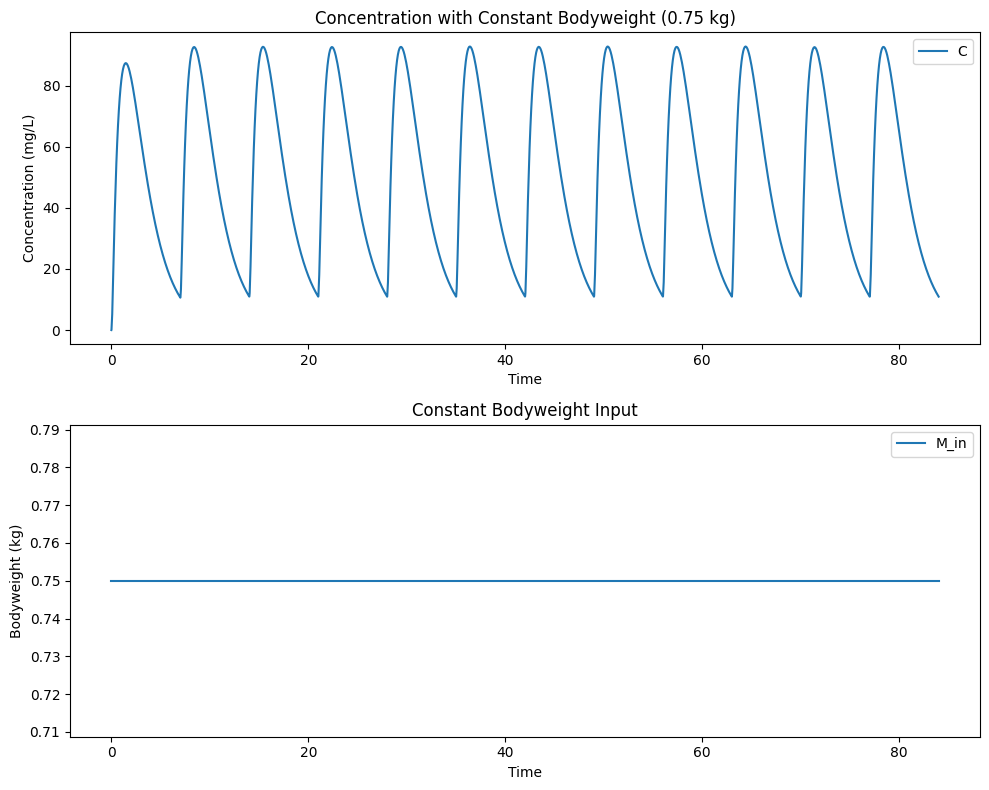

Constant bodyweight value: 0.75 kg

In [16]:
# Example 1: Using ConstFunc for constant bodyweight
# This shows how to use ConstFunc to set a constant value for an input parameter

scipy_model_const = ScipyModel(model=filename)
scipy_model_const.update_constants(OralDose=25)

# Set constant bodyweight using ConstFunc
scipy_model_const.assign_forcing_function('M_in', 'ConstFunc', value=0.75)  # 0.75 kg constant bodyweight

# Set up oral dosing
scipy_model_const.assign_forcing_function(
    'OralExp', 
    'PerDose', 
    t0=0, 
    duration=scipy_model_const.parameters['OralDur'], 
    period=7
)

# Run simulation
times = np.linspace(0, 84, 1000)
solution_const = scipy_model_const.run_model(times)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

solution_const.plot_results(variables='C', ax=ax1)
ax1.set_title('Concentration with Constant Bodyweight (0.75 kg)')
ax1.set_ylabel('Concentration (mg/L)')

# Plot the constant bodyweight input
solution_const.plot_inputs(variables='M_in', ax=ax2)
ax2.set_title('Constant Bodyweight Input')
ax2.set_ylabel('Bodyweight (kg)')

plt.tight_layout()
plt.show()

print(f"Constant bodyweight value: {scipy_model_const.forcing_functions['M_in']['kwargs']['value']} kg")

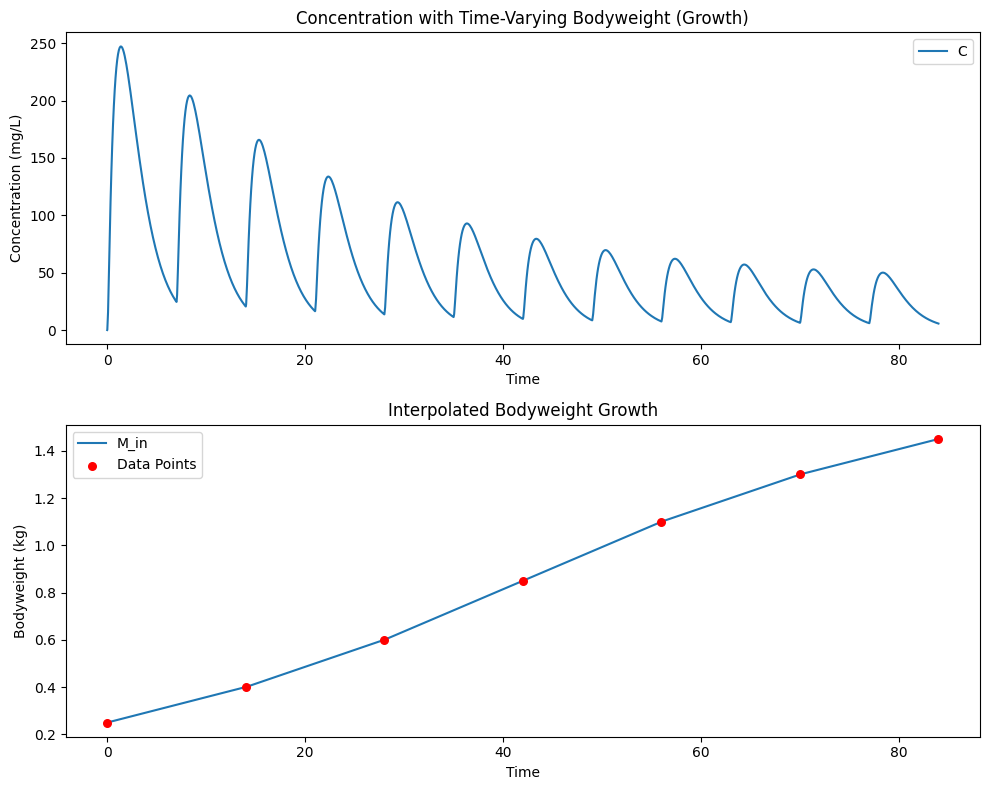

Interpolated forcing function type: Interpolate

Time points: [0, 14, 28, 42, 56, 70, 84]

Bodyweight values: [0.25, 0.4, 0.6, 0.85, 1.1, 1.3, 1.45]

In [17]:
# Example 2: Using Interpolated Forcing for time-varying bodyweight
# This demonstrates the new interpolated forcing functionality for realistic scenarios

scipy_model_interp = ScipyModel(model=filename)
scipy_model_interp.update_constants(OralDose=25)

# Create realistic bodyweight growth data
# Simulating growth over 12 weeks (84 days)
time_points = [0, 14, 28, 42, 56, 70, 84]  # Every 2 weeks
bodyweight_values = [0.25, 0.4, 0.6, 0.85, 1.1, 1.3, 1.45]  # Growth curve in kg

# Assign interpolated forcing function for bodyweight
scipy_model_interp.assign_forcing_function(
    'M_in', 'Interpolate',
    times=time_points, 
    values=bodyweight_values,
    interpolation_method='linear'
)

# Set up oral dosing
scipy_model_interp.assign_forcing_function(
    'OralExp', 
    'PerDose', 
    t0=0,  # Start dosing at day 0 (was 7)
    duration=scipy_model_interp.parameters['OralDur'], 
    period=7,  # Weekly dosing
)

# Run simulation
times = np.linspace(0, 84, 1000)
solution_interp = scipy_model_interp.run_model(times)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

solution_interp.plot_results(variables='C', ax=ax1)
ax1.set_title('Concentration with Time-Varying Bodyweight (Growth)')
ax1.set_ylabel('Concentration (mg/L)')

# Plot the interpolated bodyweight
solution_interp.plot_inputs(variables='M_in', ax=ax2)
ax2.set_title('Interpolated Bodyweight Growth')
ax2.set_ylabel('Bodyweight (kg)')
# Mark the data points
ax2.scatter(time_points, bodyweight_values, color='red', s=30, zorder=5, label='Data Points')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Interpolated forcing function type: {scipy_model_interp.forcing_functions['M_in']['function']}")
print(f"Time points: {time_points}")
print(f"Bodyweight values: {bodyweight_values}")

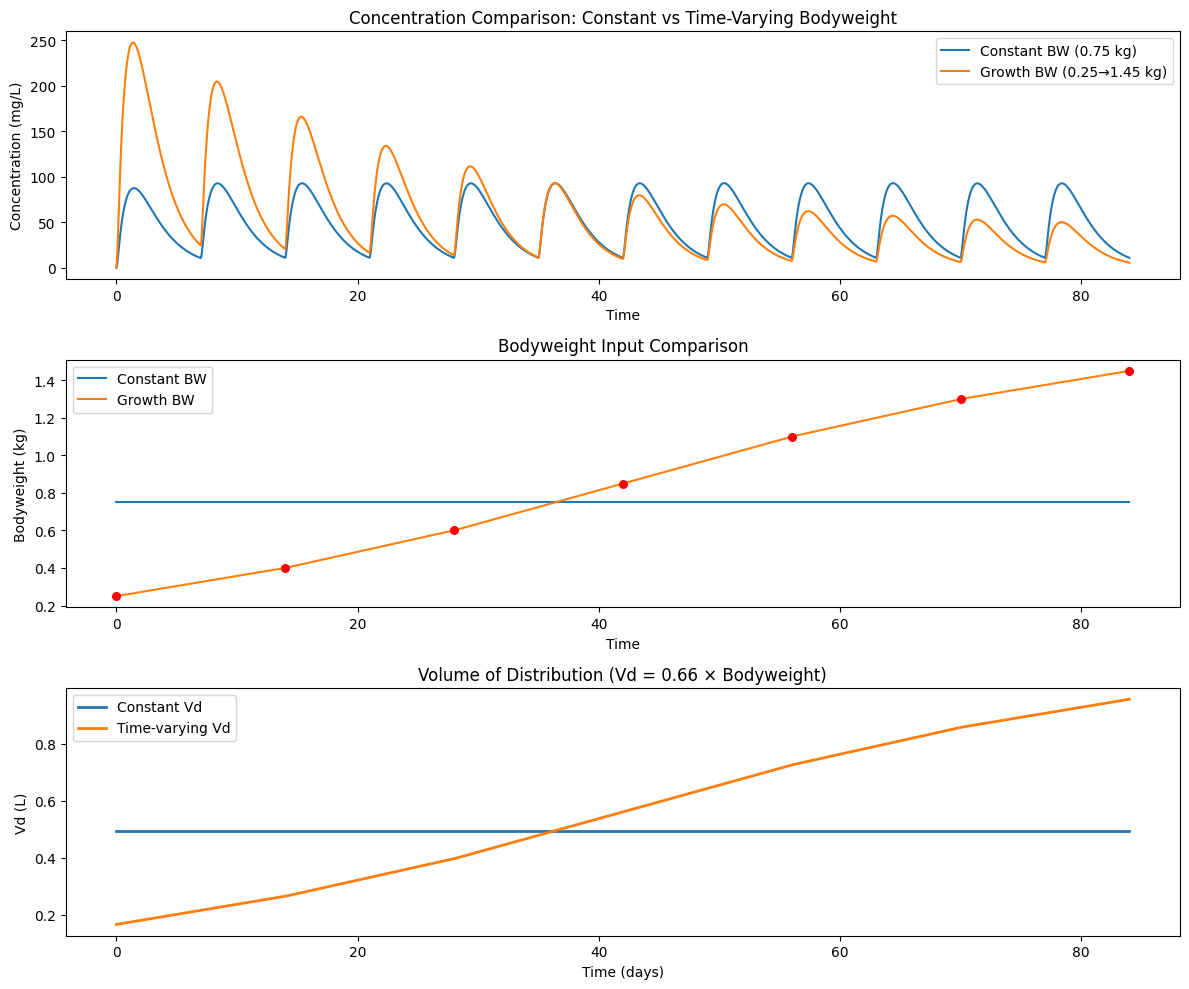

\n=== Summary Statistics ===

Constant BW Model - Max Concentration: 92.884 mg/L

Growth BW Model - Max Concentration: 247.192 mg/L

Relative difference: 166.1%

In [18]:
# Example 3: Comparison between Constant and Time-Varying Bodyweight
# This shows the impact of using realistic growth curves vs constant values

# Compare concentration profiles
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Plot concentration comparison
solution_const.plot_results(variables='C', ax=ax1, labels={'C': 'Constant BW (0.75 kg)'})
solution_interp.plot_results(variables='C', ax=ax1, labels={'C': 'Growth BW (0.25→1.45 kg)'})
ax1.set_title('Concentration Comparison: Constant vs Time-Varying Bodyweight')
ax1.set_ylabel('Concentration (mg/L)')
ax1.legend()

# Plot bodyweight inputs
solution_const.plot_inputs(variables='M_in', ax=ax2, labels={'M_in': 'Constant BW'})
solution_interp.plot_inputs(variables='M_in', ax=ax2, labels={'M_in': 'Growth BW'})
ax2.scatter(time_points, bodyweight_values, color='red', s=30, zorder=5)
ax2.set_title('Bodyweight Input Comparison')
ax2.set_ylabel('Bodyweight (kg)')
ax2.legend()

# Plot volume of distribution (Vd = Vdc * M_in)
# Extract calculated Vd values from the solutions
# For this, we need to calculate Vd manually since it's in dynamics
Vdc = 0.66  # From model parameters
times_plot = solution_const.times
vd_const = Vdc * 0.75  # constant
vd_interp = []
for t in times_plot:
    # Get interpolated bodyweight at time t
    from pymcsimmod.forcing.interpolated import InterpolatedForcing
    bw_forcing = InterpolatedForcing(time_points, bodyweight_values)
    bw_func = bw_forcing.create_function('scipy')
    vd_interp.append(Vdc * bw_func(t))

ax3.plot(times_plot, [vd_const] * len(times_plot), label='Constant Vd', linewidth=2)
ax3.plot(times_plot, vd_interp, label='Time-varying Vd', linewidth=2)
ax3.set_title('Volume of Distribution (Vd = 0.66 × Bodyweight)')
ax3.set_ylabel('Vd (L)')
ax3.set_xlabel('Time (days)')
ax3.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\\n=== Summary Statistics ===")
print(f"Constant BW Model - Max Concentration: {np.max(solution_const.aux_outputs[:, 0]):.3f} mg/L")
print(f"Growth BW Model - Max Concentration: {np.max(solution_interp.aux_outputs[:, 0]):.3f} mg/L")
print(f"Relative difference: {((np.max(solution_interp.aux_outputs[:, 0]) / np.max(solution_const.aux_outputs[:, 0])) - 1) * 100:.1f}%")